# House Price Prediction

## Import Libraries

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")

# Read Dataset

In [8]:
df=pd.read_csv("/Users/pawanpanchal/Downloads/Colombo-House-Dataset.csv")

In [9]:
df2=pd.read_csv("/Users/pawanpanchal/Downloads/Colombo-House-Dataset-3000.csv")

In [10]:
df.sample()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,STREET_NAME,FORMATTED_ADDRESS
30,Brokered by KP Agasthi Property,House for sale,"220,000,000",4,4,"3,916.00","Udahamulla, Nugegoda",Colombo,"Udahamulla, Nugegoda",Colombo,Nugegoda,NaN,"Udahamulla, Nugegoda"


In [11]:
df.shape

(100, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   BROKERTITLE                  100 non-null    object
 1   TYPE                         100 non-null    object
 2   PRICE                        100 non-null    object
 3   BEDS                         100 non-null    int64 
 4   BATH                         100 non-null    int64 
 5   PROPERTYSQFT                 100 non-null    object
 6   ADDRESS                      100 non-null    object
 7   STATE                        100 non-null    object
 8   MAIN_ADDRESS                 100 non-null    object
 9   ADMINISTRATIVE_AREA_LEVEL_2  100 non-null    object
 10  LOCALITY                     100 non-null    object
 11  STREET_NAME                  38 non-null     object
 12  FORMATTED_ADDRESS            100 non-null    object
dtypes: int64(2), object(11)
memory usage

In [ ]:
df2["MAIN_ADDRESS"].unique()

# Extract Columns

In [117]:
df3=df[["BEDS","BATH","PROPERTYSQFT","LOCALITY","PRICE"]]

In [15]:
df4=df2[["BEDS","BATH","PROPERTYSQFT","LOCALITY","PRICE"]]

In [17]:
df2.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,STREET_NAME,FORMATTED_ADDRESS
0,Brokered by Real Mart,House for sale,"94,601,238",5,5,"5,938.49","Moratuwa, Colombo",Colombo,Moratuwa,Colombo,Moratuwa,NaN,"Moratuwa, Colombo"
1,Brokered by Property Solutions,House for sale,"46,044,725",3,3,"1,768.45","Homagama, Colombo",Colombo,Homagama,Colombo,Homagama,NaN,"Homagama, Colombo"
2,Brokered by Property Solutions,House for sale,"90,985,626",5,4,"5,063.38","Boralesgamuwa, Colombo",Colombo,Boralesgamuwa,Colombo,Boralesgamuwa,NaN,"Boralesgamuwa, Colombo"
3,Brokered by Emil Realtors Pvt Ltd,House for sale,"28,967,644",3,2,"2,619.82","Piliyandala, Colombo",Colombo,Piliyandala,Colombo,Piliyandala,NaN,"Piliyandala, Colombo"
4,Brokered by Ideal Marketing,Villa for sale,"98,596,073",5,5,"4,914.25","Boralesgamuwa, Colombo",Colombo,Boralesgamuwa,Colombo,Boralesgamuwa,NaN,"Boralesgamuwa, Colombo"


In [16]:
df1.head()


NameError: name 'df1' is not defined

In [18]:
df4.head()

,BEDS,BATH,PROPERTYSQFT,LOCALITY,PRICE
0,5,5,"5,938.49",Moratuwa,"94,601,238"
1,3,3,"1,768.45",Homagama,"46,044,725"
2,5,4,"5,063.38",Boralesgamuwa,"90,985,626"
3,3,2,"2,619.82",Piliyandala,"28,967,644"
4,5,5,"4,914.25",Boralesgamuwa,"98,596,073"


In [19]:
df3.head()

,BEDS,BATH,PROPERTYSQFT,LOCALITY,PRICE
0,4,2,"2,700.00",Piliyandala,"30,000,000"
1,2,1,"2,723.00",Boralesgamuwa,"32,000,000"
2,4,4,"3,517.00",Boralesgamuwa,"145,000,000"
3,4,6,"4,400.00",Boralesgamuwa,"95,000,000"
4,7,6,"5,500.00",Boralesgamuwa,"89,000,000"


In [20]:
data = pd.concat([df3, df4], axis=0, ignore_index=True)

In [21]:
data

,BEDS,BATH,PROPERTYSQFT,LOCALITY,PRICE
0,4,2,"2,700.00",Piliyandala,"30,000,000"
1,2,1,"2,723.00",Boralesgamuwa,"32,000,000"
2,4,4,"3,517.00",Boralesgamuwa,"145,000,000"
3,4,6,"4,400.00",Boralesgamuwa,"95,000,000"
4,7,6,"5,500.00",Boralesgamuwa,"89,000,000"
...,...,...,...,...,...
3095,7,6,"8,651.21",Colombo 7,"388,281,538"
3096,2,1,"1,038.45",Padukka,"11,823,835"
3097,8,6,"6,065.41",Colombo 6,"99,001,312"
3098,3,2,"2,679.43",Piliyandala,"33,906,863"


In [22]:
data.rename(columns={'PROPERTYSQFT': 'SQFT',"BEDS":"BHK"}, inplace=True)

In [23]:
data.head()

,BHK,BATH,SQFT,LOCALITY,PRICE
0,4,2,"2,700.00",Piliyandala,"30,000,000"
1,2,1,"2,723.00",Boralesgamuwa,"32,000,000"
2,4,4,"3,517.00",Boralesgamuwa,"145,000,000"
3,4,6,"4,400.00",Boralesgamuwa,"95,000,000"
4,7,6,"5,500.00",Boralesgamuwa,"89,000,000"


# Dataset Info

In [24]:


data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   BHK       3100 non-null   int64 
 1   BATH      3100 non-null   int64 
 2   SQFT      3100 non-null   object
 3   LOCALITY  3100 non-null   object
 4   PRICE     3100 non-null   object
dtypes: int64(2), object(3)
memory usage: 121.2+ KB


In [25]:
data.shape

(3100, 5)

In [26]:
data.describe()

,BHK,BATH
count,3100.000000,3100.000000
mean,4.254839,3.619677
std,1.665925,1.412912
min,1.000000,1.000000
25%,3.000000,3.000000
50%,4.000000,3.000000
75%,5.000000,4.000000
max,10.000000,10.000000


In [27]:
# Check null 
data.isnull().sum()

BHK         0
BATH        0
SQFT        0
LOCALITY    0
PRICE       0
dtype: int64

In [28]:
# Check Duplicates
data.duplicated().sum()

136

In [29]:
data=data.drop_duplicates()

In [30]:
data.duplicated().sum()

0

In [63]:
# SQFT float to numeric

data["SQFT"] = data["SQFT"].str.replace(",", "", regex=False).astype(float)

data["PRICE"] = data["PRICE"].str.replace(",", "", regex=False).astype(float)




/var/folders/l6/hkswwbl94t53m3w117lz5qnr0000gn/T/ipykernel_43277/4293719666.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["SQFT"] = data["SQFT"].str.replace(",", "", regex=False).astype(float)


AttributeError: Can only use .str accessor with string values!

In [ ]:
data.head()

In [75]:
data.dtypes

BHK           int64
BATH          int64
SQFT        float64
LOCALITY     object
PRICE       float64
dtype: object

In [ ]:
data["PRICE"] = data["PRICE"].str.replace(",", "").astype(float)

In [76]:
data.dtypes

BHK           int64
BATH          int64
SQFT        float64
LOCALITY     object
PRICE       float64
dtype: object

In [ ]:
# Distribution of Numerical Features


In [109]:
numeric_features=["BHK","BATH","SQFT","PRICE"]

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


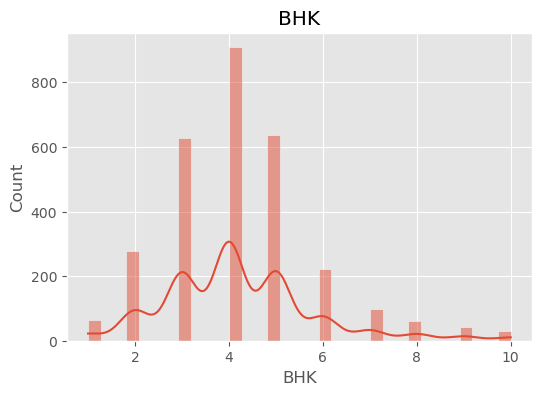

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


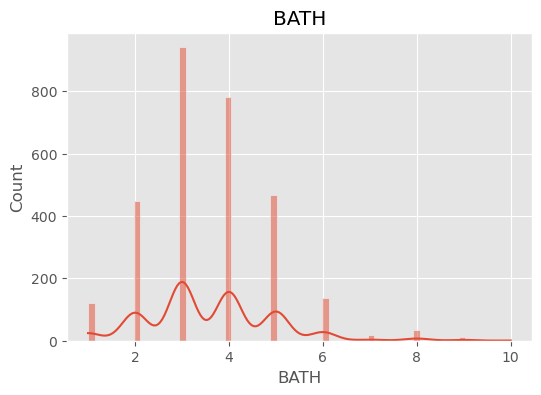

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


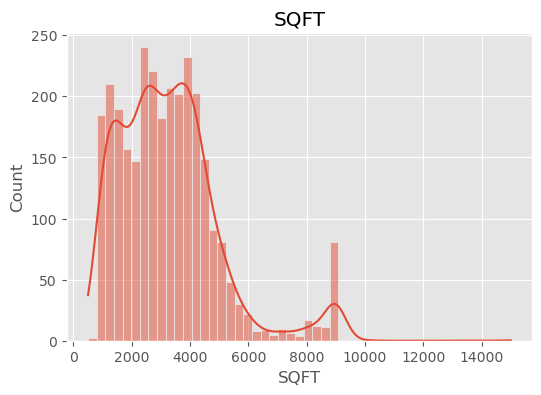

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


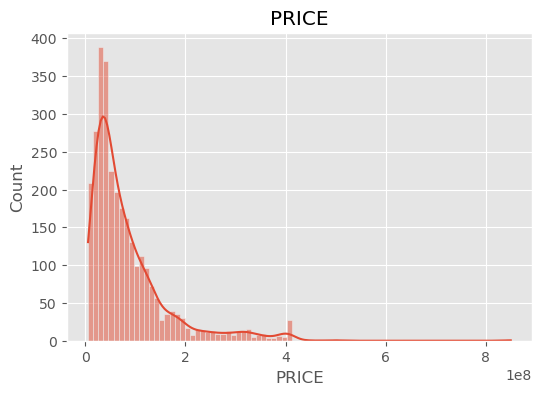

In [110]:
for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col],kde=True)
    plt.title(col)
    plt.show()

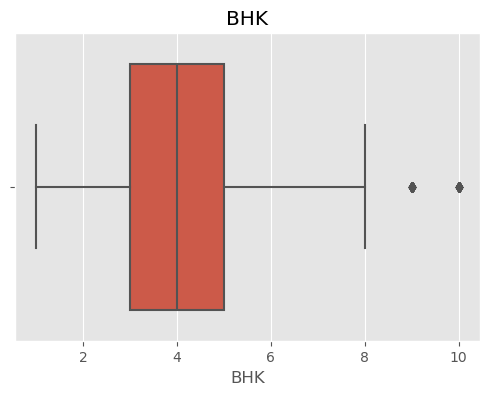

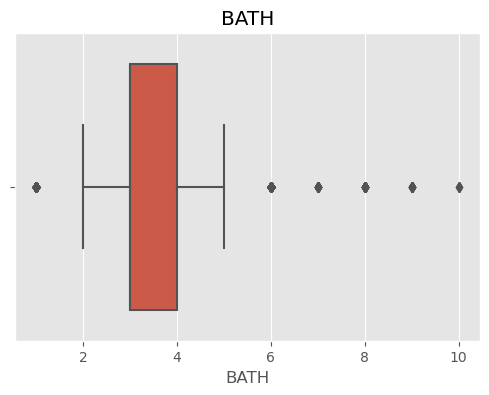

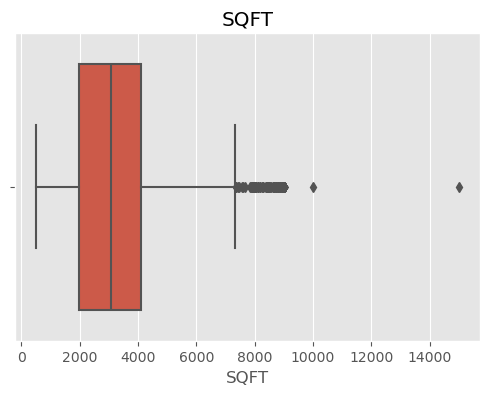

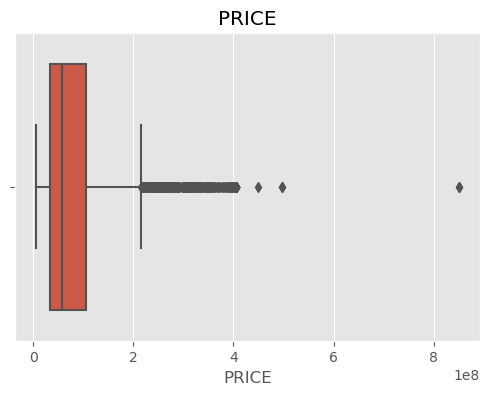

In [111]:
# Boxplots (Outlier Detection)
for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

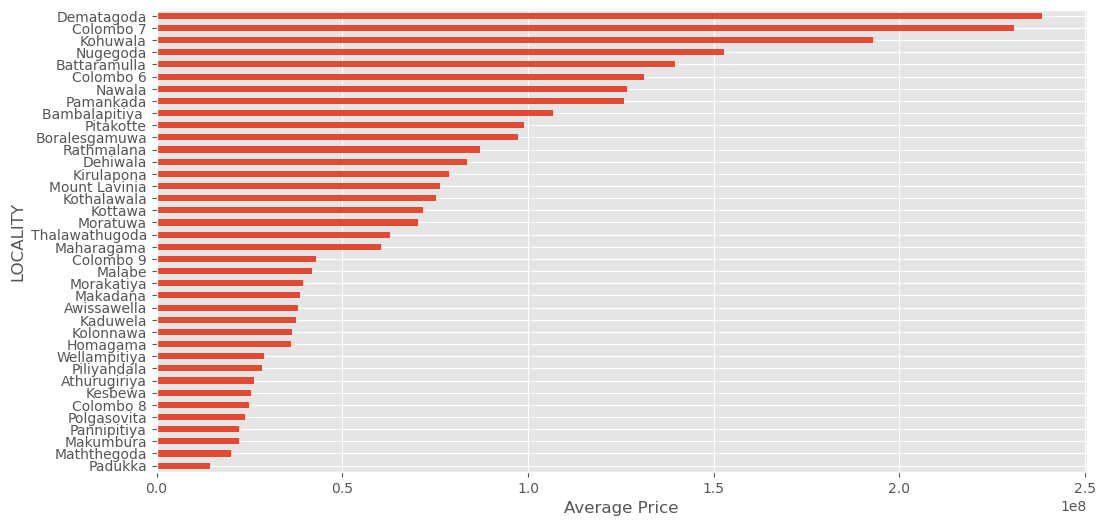

In [112]:
# Average House Price by Locality

avg_price = data.groupby("LOCALITY")["PRICE"].mean().sort_values()

plt.figure(figsize=(12,6))

avg_price.plot(kind="barh")

plt.xlabel("Average Price")

plt.show()

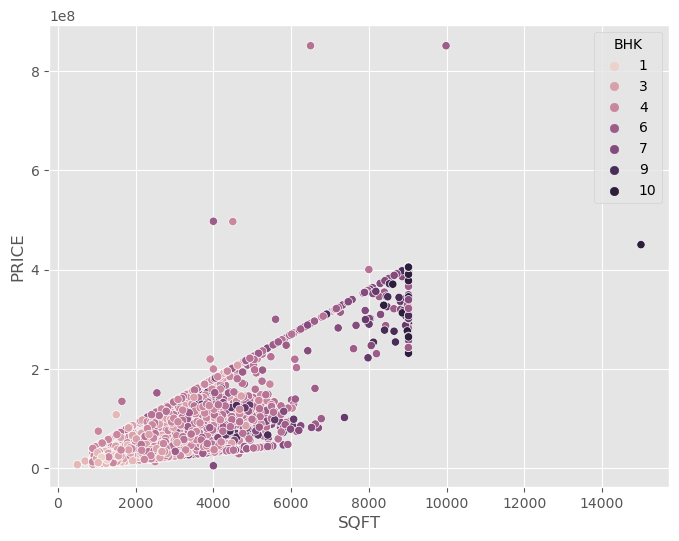

In [113]:
# Price vs Square Feet

plt.figure(figsize=(8,6))

sns.scatterplot(data=data,
               x="SQFT",
               y="PRICE",
               hue="BHK")

plt.show()

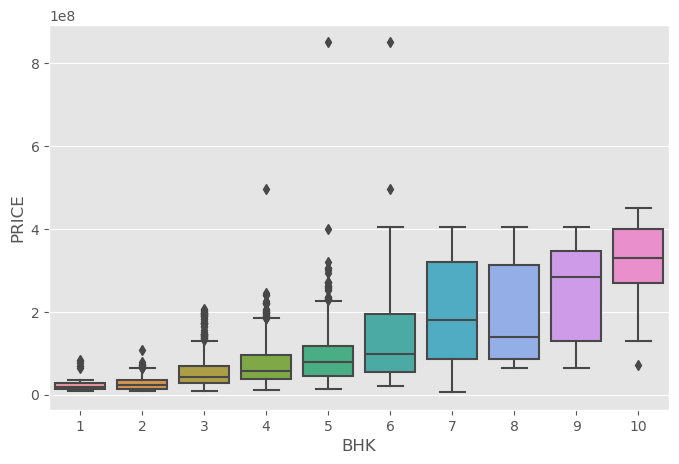

In [114]:
# Price by BHK
plt.figure(figsize=(8,5))

sns.boxplot(data=data,
            x="BHK",
            y="PRICE")

plt.show()

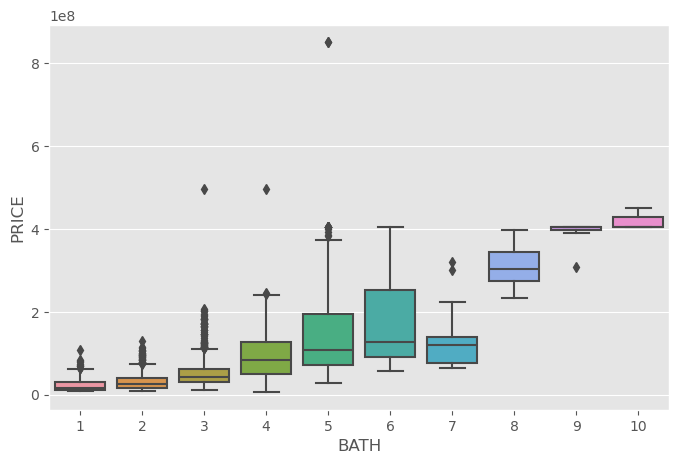

In [115]:
#Price by Bathrooms

plt.figure(figsize=(8,5))

sns.boxplot(data=data,
            x="BATH",
            y="PRICE")

plt.show()

In [64]:
# Top 10 Expensive Houses

data.sort_values("PRICE", ascending=False).head(10)

,BHK,BATH,SQFT,LOCALITY,PRICE
54,6,5,9985.0,Colombo 7,850000000.0
50,5,5,6500.0,Colombo 7,850000000.0
53,6,3,4000.0,Colombo 7,497000000.0
52,4,4,4500.0,Colombo 7,496440000.0
96,10,10,15000.0,Dematagoda,450000000.0
2190,10,10,9019.7,Pamankada,404819885.0
3094,10,9,9019.7,Nawala,404819885.0
406,9,9,9019.7,Battaramulla,404819885.0
1665,9,6,9019.7,Nawala,404819885.0
2175,10,9,9019.7,Colombo 7,404819885.0


In [65]:
# Cheapest Houses
data.sort_values("PRICE").head(10)

,BHK,BATH,SQFT,LOCALITY,PRICE
56,7,4,4000.0,Mount Lavinia,5500000.0
2301,1,2,896.0,Pannipitiya,7777000.0
706,1,1,896.0,Wellampitiya,7777000.0
546,1,2,896.0,Wellampitiya,7777000.0
602,2,2,896.0,Wellampitiya,7777000.0
2056,1,1,896.0,Colombo 8,7777000.0
1656,3,1,896.0,Wellampitiya,7777000.0
2346,3,1,896.0,Polgasovita,7777000.0
710,2,2,896.0,Piliyandala,7777000.0
892,1,1,896.0,Athurugiriya,7777000.0


# Features & Targets

In [78]:
x=data.drop("PRICE",axis=1)
y=data["PRICE"]

In [79]:
#Train-Test Split

from sklearn.model_selection import train_test_split



In [89]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# Preprocessing Pipeline

In [90]:
num_features=["BHK","BATH","SQFT"]
cat_features=["LOCALITY"]


In [91]:
numeric_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="median"))
])

In [92]:
cat_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

In [93]:
Preprocessor=ColumnTransformer([
    ("num",numeric_transformer,num_features),
    ("cat",cat_transformer,cat_features)
])

In [94]:
Preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['BHK', 'BATH', 'SQFT']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['LOCALITY'])])

In [100]:
pipe.fit(x_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['BHK', 'BATH', 'SQFT']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['LOCALITY'])])),
                ('model', RandomForestRegressor(random_state=42))])

# Train and Evaluate Models

In [99]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("Preprocessor", Preprocessor),
        ("model", model)
    ])

    pipe.fit(x_train, y_train)

    predictions = pipe.predict(x_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

results = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

print(results.sort_values("R2 Score", ascending=False))

           Model           MAE          RMSE  R2 Score
2  Random Forest  1.542640e+07  2.864723e+07  0.876243
0         Linear  2.505944e+07  3.583090e+07  0.806393
1  Decision Tree  1.847404e+07  3.650990e+07  0.798986


In [101]:
y_pred = pipe.predict(x_test)

# Save the Best Model

In [104]:
import joblib

best_model = Pipeline([
    ("Preprocessor", Preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

best_model.fit(x_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['BHK', 'BATH', 'SQFT']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['LOCALITY'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [105]:
best_model.fit(x_train, y_train)

Pipeline(steps=[('Preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['BHK', 'BATH', 'SQFT']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['LOCALITY'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

# redict on New Data

In [106]:
new_house = pd.DataFrame({
    "BHK": [3],
    "BATH": [2],
    "SQFT": [1800],
    "LOCALITY": ["Boralesgamuwa"]
})

prediction = best_model.predict(new_house)

print("Predicted Price:", prediction[0])

Predicted Price: 32535632.7


In [107]:
joblib.dump(best_model, "colombo_house.pkl")

['colombo_house.pkl']